# Roteamento de drone de entrega com vento dinâmico

Aluno: Otávio Muck Schein

Vídeo da apresentação: (inserir link do YouTube)

## 1. Introdução

Entregas por drone são uma aplicação real em crescimento, e trazem um problema de decisão sequencial natural: o drone precisa cumprir prazos, mas sua autonomia depende da bateria, e o consumo varia com as condições do tempo. Voar direto para a entrega economiza tempo, mas pode esgotar a bateria longe da estação; voltar para recarregar é seguro, mas pode fazer os prazos expirarem.

Este trabalho modela esse problema como um MDP e o implementa como um ambiente inédito no Gymnasium. Um drone opera em uma cidade representada por um grid de 8x8, precisa coletar e entregar 3 pacotes com prazo por episódio e enfrenta um vento que muda de forma estocástica ao longo do tempo, tornando cada movimento mais barato ou mais caro dependendo da direção. Ficar sem bateria fora da estação encerra o episódio com uma penalidade grande.

Foram comparados três algoritmos de aprendizado por reforço profundo do stable-baselines3: DQN, A2C e PPO. Os experimentos incluem uma etapa de desenvolvimento para tornar o problema aprendível (reward shaping, ajustes na representação do estado e um currículo de treinamento), a otimização de hiperparâmetros por busca em grade (24 configurações), um experimento adicional sobre o desconto do shaping e uma avaliação final em 100 episódios contra dois baselines: uma política aleatória e uma heurística escrita à mão.

Principais descobertas:

- Os três algoritmos superaram com folga os baselines. O melhor agente, o PPO otimizado, obteve 39.5 de recompensa média, contra 9.8 da heurística, entregando em média 2.38 dos 3 pacotes por episódio.
- As políticas aprendidas representam pontos diferentes do trade-off entre prazo e bateria: a heurística nunca cai mas perde muitos pacotes por expiração, o A2C entrega quase tudo mas cai em quase metade dos episódios, e o PPO otimizado encontra o melhor equilíbrio, com 16% de queda.
- A otimização de hiperparâmetros teve grande efeito no DQN (de 8.8 para 25.0, principalmente pela redução do replay buffer), reduziu pela metade a taxa de queda do PPO e não teve efeito no A2C.
- Reward shaping, a representação do estado com vetores relativos e o currículo de bateria foram decisivos: sem eles, nenhum agente aprendeu a entregar.

O notebook está organizado da seguinte forma: a seção 2 apresenta o MDP e a implementação do ambiente; a seção 3 descreve a metodologia, incluindo o processo de desenvolvimento; a seção 4 apresenta e discute os resultados; e a seção 5 traz as conclusões, limitações e trabalhos futuros.

## 2. Modelagem do problema

O problema modela um drone de entregas operando em uma cidade representada por um grid de 8x8 células. A cada episódio surgem 3 pacotes, cada um com um ponto de coleta, um destino e um prazo. O drone parte da estação de recarga, no canto (0, 0), com a bateria cheia, e precisa coletar e entregar os pacotes enfrentando um vento que muda ao longo do tempo e altera o custo de cada movimento.

O desafio central é um trade-off: cumprir os prazos exige se mover bastante, mas ficar sem bateria longe da estação encerra o episódio com uma penalidade grande. O agente precisa decidir quando vale a pena desviar para recarregar e quando vale arriscar seguir direto para a entrega.

O problema foi formulado como um MDP (S, A, P, R, gamma), descrito a seguir.

Estado (S). O estado contém:

- a posição do drone (x, y);
- a carga atual da bateria;
- o vento atual e o vento do passo anterior (cada um um vetor de duas componentes em [-1, 1]);
- para cada um dos 3 pacotes: posição de coleta, posição de destino, prazo restante e status (aguardando coleta, carregado pelo drone ou concluído).

O vento anterior foi incluído por sugestão do professor na validação da proposta. Como o vento evolui de forma correlacionada, observar apenas o valor atual não permite perceber a tendência de mudança; com os dois valores, o estado passa a conter a direção em que o vento está variando.

Ações (A). Espaço discreto com 8 ações: mover para norte, sul, leste ou oeste; coletar pacote; entregar pacote; recarregar; esperar.

Transição (P).

- Mover gasta bateria de acordo com o vento: custo = 2.0 - 1.5 x (alinhamento entre a direção do movimento e o vento). Com vento forte a favor o custo cai para 0.5; contra, sobe para 3.5. Tentar sair do grid não move o drone.
- Coletar só tem efeito se o drone estiver na célula de coleta de um pacote aguardando e não estiver carregando outro. Entregar só tem efeito se o drone estiver carregando um pacote e estiver no destino dele.
- Recarregar só tem efeito na estação e recupera 25 unidades de bateria, até o máximo de 60.
- Esperar fora da estação gasta 0.5 de bateria (o drone paira no ar).
- Após a ação, o vento evolui de forma estocástica e o prazo de cada pacote não concluído diminui em 1.
- Um pacote com mais de 15 passos de atraso expira e é considerado concluído sem entrega.

Recompensa (R).

- +10 por entrega dentro do prazo;
- entrega atrasada: recompensa parcial que começa em +5 e cai linearmente até 0 ao fim da janela de 15 passos de atraso;
- -5 por pacote expirado;
- -0.1 por passo, como incentivo à eficiência;
- -0.5 por ação inválida (coletar, entregar ou recarregar fora das condições, ou tentar sair do grid);
- -50 se a bateria chegar a zero fora da estação.

Além desses termos, a recompensa inclui um componente de reward shaping, que se mostrou necessário para o aprendizado e é descrito na seção 3.

Terminação. O episódio termina quando a bateria chega a zero fora da estação (queda do drone) ou quando todos os pacotes foram concluídos (entregues ou expirados). Ele também é truncado ao atingir 200 passos.

Fator de desconto. gamma = 0.99, o padrão dos algoritmos do stable-baselines3. Um valor alto é adequado porque as consequências de gastar bateria só aparecem vários passos depois da decisão.

As células a seguir definem a configuração do ambiente. Todos os parâmetros ficam centralizados em constantes, o que facilita justificar cada valor e testar variações.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env

from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback

In [2]:
# Environment configuration
GRID_SIZE = 8                 # 8x8 city grid
STATION_POS = (0, 0)          # charging station location
N_PACKAGES = 3                # fixed number of packages per episode
MAX_BATTERY = 60.0            # real battery capacity
CURRICULUM_BATTERY = 100.0    # generous battery used in the first curriculum stage
BATTERY_SCALE = 100.0         # fixed scale for the battery observation
BASE_MOVE_COST = 2.0          # battery cost per move with no wind
WIND_EFFECT = 1.5             # how much wind changes the move cost
WIND_SIGMA = 0.15             # random walk noise for wind evolution
WIND_PERSISTENCE = 0.9        # fraction of the current wind kept in the next step
CHARGE_RATE = 25.0            # battery recovered per recharge action
HOVER_COST = 0.5              # battery spent when waiting outside the station
MAX_STEPS = 200
DEADLINE_RANGE = (20, 50)     # min/max initial deadline (in steps)
LATE_WINDOW = 15              # steps after the deadline before a package expires

# Actions
ACTIONS = {
    0: "north", 1: "south", 2: "east", 3: "west",
    4: "pickup", 5: "deliver", 6: "recharge", 7: "wait",
}
MOVES = {0: (0, 1), 1: (0, -1), 2: (1, 0), 3: (-1, 0)}

# Package status codes
WAITING, CARRIED, DONE = 0, 1, 2

# Rewards
DELIVERY_REWARD = 10.0
LATE_FACTOR = 0.5             # late delivery gets at most half the reward, decaying to zero
EXPIRE_PENALTY = -5.0
STEP_PENALTY = -0.1
CRASH_PENALTY = -50.0
INVALID_PENALTY = -0.5        # pickup/deliver/recharge/move not allowed in the current state

# Reward shaping (potential-based, progress + distance to target)
SHAPING_WEIGHT = 0.5
SHAPING_GAMMA = 1.0           # undiscounted shaping: waiting costs exactly STEP_PENALTY
STAGE_VALUE = 2 * (GRID_SIZE - 1)  # max Manhattan distance: completing a stage always raises the potential

### 2.1 Dinâmica do vento

O vento é um vetor (wx, wy) com componentes em [-1, 1], igual em todas as células do grid. Essa simplificação (um vento global em vez de um campo de ventos por célula) mantém o problema tratável e preserva o efeito principal: o custo de cada direção de movimento muda ao longo do episódio.

A evolução segue um random walk correlacionado: o vento do próximo passo mantém 90% do valor atual e recebe um ruído gaussiano com desvio padrão 0.15, sendo limitado ao intervalo [-1, 1]. O fator de 0.9 faz o vento mudar de forma gradual e também o puxa de volta em direção ao zero, evitando que fique preso nos valores extremos.

O custo de um movimento usa o produto escalar entre a direção do movimento e o vento, que vale +1 com vento totalmente a favor e -1 com vento totalmente contra.

In [3]:
def next_wind(wind, rng):
    "Correlated random walk: next wind depends on current wind plus noise"
    noise = rng.normal(0.0, WIND_SIGMA, size=2)
    new_wind = WIND_PERSISTENCE * wind + noise
    return np.clip(new_wind, -1.0, 1.0)

def move_cost(direction, wind):
    "Battery cost of moving in a direction under the current wind. Tailwind (same direction) lowers the cost, headwind raises it"
    alignment = np.dot(direction, wind)  # +1 tailwind, -1 headwind
    return BASE_MOVE_COST - WIND_EFFECT * alignment

A célula abaixo simula alguns passos com um vento inicial soprando para o leste, mostrando dois comportamentos da transição do MDP:

- o vento evolui de forma gradual (random walk correlacionado), mantendo parte do valor anterior a cada passo;
- o custo de bateria depende da direção do movimento em relação ao vento: mover a favor (leste) custa menos que mover contra (oeste).

In [4]:
rng = np.random.default_rng(42)
wind = np.array([0.5, 0.0])  # wind blowing east

for t in range(5):
    east = move_cost(np.array(MOVES[2]), wind)
    west = move_cost(np.array(MOVES[3]), wind)
    print(f"t={t} wind={wind.round(2)} cost_east={east:.2f} cost_west={west:.2f}")
    wind = next_wind(wind, rng)

t=0 wind=[0.5 0. ] cost_east=1.25 cost_west=2.75
t=1 wind=[ 0.5  -0.16] cost_east=1.26 cost_west=2.74
t=2 wind=[0.56 0.  ] cost_east=1.16 cost_west=2.84
t=3 wind=[ 0.21 -0.19] cost_east=1.68 cost_west=2.32
t=4 wind=[ 0.21 -0.22] cost_east=1.69 cost_west=2.31


### 2.2 Ambiente

O ambiente foi implementado como uma classe do Gymnasium (`DroneDeliveryEnv`), com os métodos padrão `reset`, `step` e `render`. Algumas decisões de implementação merecem destaque.

Observação. A observação é um vetor de 35 valores, todos normalizados para [-1, 1], escala em que as redes neurais treinam melhor. O número de pacotes é fixo porque o Gymnasium exige uma observação de tamanho fixo. O status de cada pacote é codificado em one-hot, o que já representa qual pacote o drone está carregando.

Além do estado descrito no MDP, a observação inclui dois vetores derivados: a direção relativa do drone até o alvo atual (o pacote aguardando mais próximo, ou o destino do pacote carregado) e até a estação de recarga. Esses vetores não adicionam informação nova, pois são calculados a partir do estado, mas foram decisivos para o aprendizado: sem eles, a rede precisaria aprender sozinha a subtrair coordenadas absolutas que mudam a cada episódio (ver seção 3).

Bateria configurável. A capacidade máxima da bateria é um parâmetro do ambiente, usado no currículo de treinamento descrito na seção 3. Na observação, a bateria é dividida por uma escala fixa de 100, para que um mesmo valor observado represente a mesma carga em qualquer configuração.

Métricas por episódio. O `step` retorna, no dicionário `info`, a quantidade de entregas no prazo, entregas atrasadas, pacotes expirados e se houve queda. Essas métricas são a base da avaliação, já que a recompensa total sozinha não mostra como o agente se comporta.

Renderização. O `render` desenha o grid com matplotlib: a estação em verde, o drone em azul (com um quadrado marrom quando está carregando um pacote), os pontos de coleta como quadrados marrons numerados, os destinos como X vermelhos com o número do pacote e o prazo restante, e setas cinzas representando o vento. O título mostra o passo, a bateria e o vento. São suportados os modos `human`, que exibe a imagem, e `rgb_array`, que retorna a imagem como array e é usado para gerar os GIFs da seção 4.5.

In [5]:
class DroneDeliveryEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 4}

    def __init__(self, render_mode=None, reward_shaping=True, max_battery=MAX_BATTERY, shaping_gamma=SHAPING_GAMMA):
        super().__init__()
        self.render_mode = render_mode
        self.reward_shaping = reward_shaping
        self.max_battery = max_battery
        self.shaping_gamma = shaping_gamma

        # 8 discrete actions: 4 moves, pickup, deliver, recharge, wait
        self.action_space = spaces.Discrete(len(ACTIONS))

        # Observation layout (all values in [-1, 1]):
        # drone x, y (2) + battery (1) + current wind (2) + previous wind (2)
        # + relative vector to current target (2) + relative vector to station (2)
        # + per package: pickup x, y, destination x, y, deadline, status one-hot (3) = 8
        obs_size = 2 + 1 + 2 + 2 + 2 + 2 + N_PACKAGES * 8
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(obs_size,), dtype=np.float32)

    # observation

    def _norm_pos(self, pos):
        return np.array(pos, dtype=np.float32) / (GRID_SIZE - 1)

    def _get_obs(self):
        target = self._current_target() or self.drone_pos
        rel_target = (np.array(target) - np.array(self.drone_pos)) / (GRID_SIZE - 1)
        rel_station = (np.array(STATION_POS) - np.array(self.drone_pos)) / (GRID_SIZE - 1)

        parts = [
            self._norm_pos(self.drone_pos),
            [self.battery / BATTERY_SCALE],
            self.wind,
            self.prev_wind,
            rel_target,
            rel_station,
        ]
        for pkg in self.packages:
            status_one_hot = np.zeros(3, dtype=np.float32)
            status_one_hot[pkg["status"]] = 1.0
            deadline = np.clip(pkg["deadline"] / DEADLINE_RANGE[1], -1.0, 1.0)
            parts += [
                self._norm_pos(pkg["pickup"]),
                self._norm_pos(pkg["dest"]),
                [deadline],
                status_one_hot,
            ]
        return np.concatenate(parts).astype(np.float32)

    # episode setup

    def _random_cell(self):
        "Random grid cell, excluding the charging station."
        while True:
            cell = tuple(int(v) for v in self.np_random.integers(0, GRID_SIZE, size=2))
            if cell != STATION_POS:
                return cell

    def _random_package(self):
        pickup = self._random_cell()
        dest = self._random_cell()
        while dest == pickup:
            dest = self._random_cell()
        deadline = int(self.np_random.integers(DEADLINE_RANGE[0], DEADLINE_RANGE[1] + 1))
        return {"pickup": pickup, "dest": dest, "deadline": deadline, "status": WAITING}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0
        self.drone_pos = STATION_POS
        self.battery = self.max_battery
        self.wind = self.np_random.uniform(-0.5, 0.5, size=2)
        self.prev_wind = self.wind.copy()
        self.packages = [self._random_package() for _ in range(N_PACKAGES)]
        self.stats = {"on_time": 0, "late": 0, "expired": 0, "crashed": False}
        self._last_potential = self._potential()
        return self._get_obs(), {}

    # helpers

    def _carried_package(self):
        for pkg in self.packages:
            if pkg["status"] == CARRIED:
                return pkg
        return None

    def _current_target(self):
        "Closest waiting pickup, or the destination of the carried package"
        carried = self._carried_package()
        if carried is not None:
            return carried["dest"]
        x, y = self.drone_pos
        waiting = [p["pickup"] for p in self.packages if p["status"] == WAITING]
        if not waiting:
            return None
        return min(waiting, key=lambda c: abs(c[0] - x) + abs(c[1] - y))

    def _potential(self):
        "Progress-based potential: completed stages minus distance to the current target"
        carried = sum(p["status"] == CARRIED for p in self.packages)
        delivered = self.stats["on_time"] + self.stats["late"]
        progress = carried + 2 * delivered

        target = self._current_target()
        dist = 0
        if target is not None:
            x, y = self.drone_pos
            dist = abs(target[0] - x) + abs(target[1] - y)
        return SHAPING_WEIGHT * (STAGE_VALUE * progress - dist)

    # actions

    def _apply_move(self, action):
        dx, dy = MOVES[action]
        new_x, new_y = self.drone_pos[0] + dx, self.drone_pos[1] + dy
        if not (0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE):
            return INVALID_PENALTY  # hit the grid border, stays in place
        self.battery -= move_cost(np.array([dx, dy]), self.wind)
        self.drone_pos = (new_x, new_y)
        return 0.0

    def _apply_pickup(self):
        if self._carried_package() is not None:
            return INVALID_PENALTY
        for pkg in self.packages:
            if pkg["status"] == WAITING and pkg["pickup"] == self.drone_pos:
                pkg["status"] = CARRIED
                return 0.0
        return INVALID_PENALTY

    def _apply_deliver(self):
        pkg = self._carried_package()
        if pkg is None or pkg["dest"] != self.drone_pos:
            return INVALID_PENALTY
        pkg["status"] = DONE
        if pkg["deadline"] >= 0:
            self.stats["on_time"] += 1
            return DELIVERY_REWARD
        self.stats["late"] += 1
        lateness = -pkg["deadline"]
        return DELIVERY_REWARD * LATE_FACTOR * (1 - lateness / LATE_WINDOW)

    def _apply_recharge(self):
        if self.drone_pos != STATION_POS:
            return INVALID_PENALTY
        self.battery = min(self.max_battery, self.battery + CHARGE_RATE)
        return 0.0

    # transition

    def step(self, action):
        action = int(action)
        self.steps += 1
        reward = STEP_PENALTY

        if action in MOVES:
            reward += self._apply_move(action)
        elif action == 4:
            reward += self._apply_pickup()
        elif action == 5:
            reward += self._apply_deliver()
        elif action == 6:
            reward += self._apply_recharge()
        elif action == 7 and self.drone_pos != STATION_POS:
            self.battery -= HOVER_COST

        # Wind evolves after the action
        self.prev_wind = self.wind
        self.wind = next_wind(self.wind, self.np_random)

        # Deadlines tick down; packages that are too late expire
        for pkg in self.packages:
            if pkg["status"] != DONE:
                pkg["deadline"] -= 1
                if pkg["deadline"] < -LATE_WINDOW:
                    pkg["status"] = DONE
                    self.stats["expired"] += 1
                    reward += EXPIRE_PENALTY

        terminated = False
        if self.battery <= 0 and self.drone_pos != STATION_POS:
            reward += CRASH_PENALTY
            self.stats["crashed"] = True
            terminated = True
        elif all(pkg["status"] == DONE for pkg in self.packages):
            terminated = True
        self.battery = max(self.battery, 0.0)

        if self.reward_shaping:
            new_potential = self._potential()
            reward += self.shaping_gamma * new_potential - self._last_potential
            self._last_potential = new_potential

        truncated = self.steps >= MAX_STEPS
        return self._get_obs(), reward, terminated, truncated, dict(self.stats)

    # rendering

    def _draw(self):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, GRID_SIZE - 0.5)
        ax.set_ylim(-0.5, GRID_SIZE - 0.5)
        ax.set_xticks(range(GRID_SIZE))
        ax.set_yticks(range(GRID_SIZE))
        ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
        ax.grid(which="minor", color="lightgray")
        ax.set_aspect("equal")

        # Wind field (same wind in every cell)
        xs, ys = np.meshgrid(range(GRID_SIZE), range(GRID_SIZE))
        ax.quiver(xs, ys,
                  np.full_like(xs, self.wind[0], dtype=float),
                  np.full_like(ys, self.wind[1], dtype=float),
                  color="gray", alpha=0.3, scale=12)

        # Charging station
        sx, sy = STATION_POS
        ax.add_patch(plt.Rectangle((sx - 0.5, sy - 0.5), 1, 1, color="lightgreen"))
        ax.text(sx, sy - 0.35, "station", ha="center", fontsize=7)

        # Packages: square = pickup, X = destination, label = id:deadline
        dest_labels = {}
        for i, pkg in enumerate(self.packages):
            if pkg["status"] == DONE:
                continue
            if pkg["status"] == WAITING:
                px, py = pkg["pickup"]
                ax.plot(px, py, marker="s", color="tab:brown", markersize=14)
                ax.text(px, py, str(i), ha="center", va="center", color="white", fontsize=8)
            dest_labels.setdefault(pkg["dest"], []).append(f"{i}:{pkg['deadline']}")

        for (dx, dy), labels in dest_labels.items():
            ax.plot(dx, dy, marker="X", color="tab:red", markersize=12)
            ax.text(dx + 0.25, dy + 0.25, " ".join(labels), fontsize=8)

        # Drone (with a small square if carrying a package)
        x, y = self.drone_pos
        ax.plot(x, y, marker="o", color="tab:blue", markersize=18)
        if self._carried_package() is not None:
            ax.plot(x, y, marker="s", color="tab:brown", markersize=7)

        ax.set_title(
            f"Step {self.steps} | Battery {self.battery:.0f}/{self.max_battery:.0f} | "
            f"Wind ({self.wind[0]:+.2f}, {self.wind[1]:+.2f})"
            )
        return fig

    def render(self):
        fig = self._draw()
        if self.render_mode == "rgb_array":
            fig.canvas.draw()
            frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
            plt.close(fig)
            return frame
        plt.show()

O registro permite criar o ambiente com `gym.make("DroneDelivery-v0")`, forma utilizada pelo stable-baselines3.

In [6]:
gym.register(id="DroneDelivery-v0", entry_point=DroneDeliveryEnv)

### 2.3 Validação do ambiente

Antes dos experimentos, o ambiente foi verificado com o `check_env` do Gymnasium, que testa se ele segue o contrato da API: espaços de observação e ação, retornos do `reset` e do `step` e modos de renderização. As primeiras imagens abaixo são geradas pelo próprio `check_env` ao testar o modo `human`.

Em seguida, a célula mostra o estado inicial de um episódio e o estado após três movimentos (leste, leste, norte), permitindo conferir o deslocamento do drone, o consumo de bateria e a variação do vento.

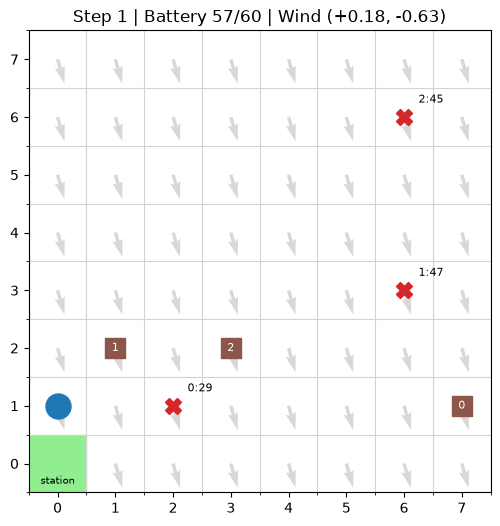

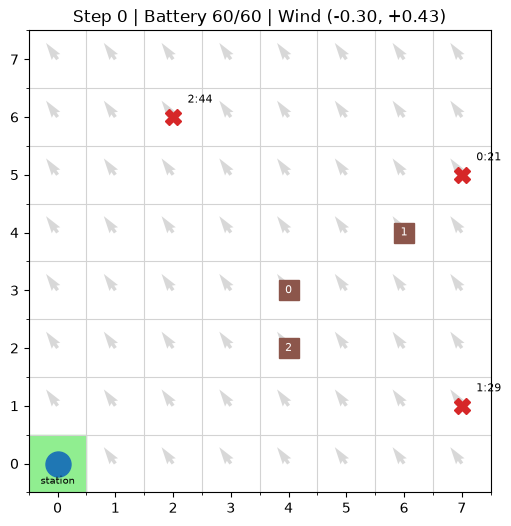

observation shape: (35,)


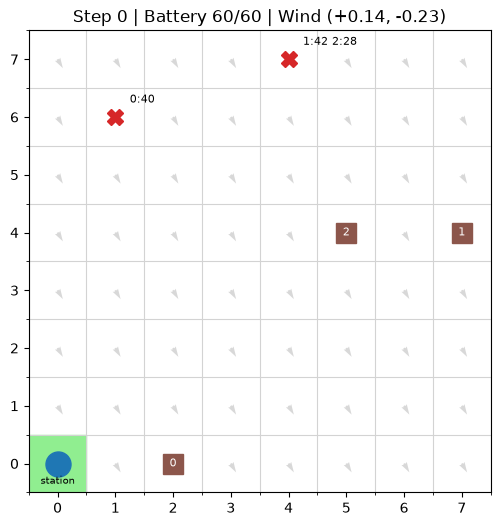

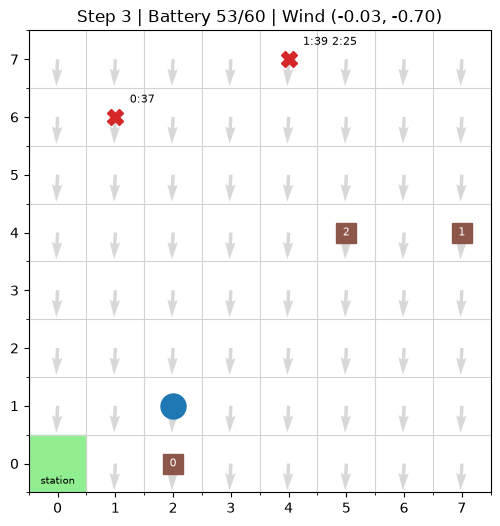

In [7]:
env = gym.make("DroneDelivery-v0", render_mode="human")
check_env(env.unwrapped)

obs, info = env.reset(seed=0)
print("observation shape:", obs.shape)
env.render()

for action in [2, 2, 0]:  # east, east, north
    env.step(action)
env.render()

## 3. Metodologia de experimentos

Foram avaliados três algoritmos de aprendizado por reforço profundo do stable-baselines3, todos compatíveis com o espaço de ações discreto do ambiente:

- DQN (Deep Q-Network): método baseado em valor e off-policy. Aprende uma estimativa do retorno de cada ação (função Q) usando um replay buffer de experiências passadas e explora com uma estratégia epsilon-greedy.
- A2C (Advantage Actor-Critic): método actor-critic on-policy. Aprende ao mesmo tempo uma política (ator) e uma estimativa de valor (crítico), atualizando a rede com trajetórias curtas e recentes.
- PPO (Proximal Policy Optimization): também actor-critic on-policy, mas limita o tamanho de cada atualização da política (clipping), o que tende a tornar o treinamento mais estável.

Algoritmos de ação contínua do stable-baselines3 (SAC, TD3 e DDPG) foram descartados por serem incompatíveis com a formulação do problema.

Todos os agentes usam a política `MlpPolicy` (rede totalmente conectada, adequada a uma observação vetorial), treinam com 4 cópias do ambiente em paralelo e usam seed fixa.

### 3.1 Avaliação

A avaliação usa uma função única para todas as políticas (baselines e agentes treinados), sempre com as mesmas seeds de episódio, para que a comparação seja justa. As métricas são:

- recompensa média por episódio (e desvio padrão);
- média de entregas no prazo, de entregas atrasadas e de pacotes expirados por episódio;
- taxa de queda (fração dos episódios em que a bateria chegou a zero fora da estação).

As métricas de entregas e queda são essenciais porque a recompensa total mistura vários termos: duas políticas com recompensa parecida podem ter comportamentos bem diferentes, como veremos nos resultados.

Os agentes são avaliados com a política estocástica (amostrando ações), a mesma usada durante o treinamento. Foram usados três conjuntos de seeds separados: seeds a partir de 1000 (20 episódios) no acompanhamento durante o treino, a partir de 2000 (50 episódios) na seleção de hiperparâmetros e a partir de 10000 (100 episódios) na avaliação final. Assim, a configuração é escolhida em um conjunto de episódios e medida em outro.

In [8]:
def evaluate(policy_fn, n_episodes=20, seed=1000):
    "Runs a policy on fixed seeds and returns the mean episode metrics"
    env = gym.make("DroneDelivery-v0")
    env.action_space.seed(seed)
    rewards, on_time, late, expired, crashes = [], [], [], [], []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            obs, reward, terminated, truncated, info = env.step(policy_fn(obs, env))
            total += reward
            done = terminated or truncated
        rewards.append(total)
        on_time.append(info["on_time"])
        late.append(info["late"])
        expired.append(info["expired"])
        crashes.append(info["crashed"])
    return {
        "reward_mean": np.mean(rewards),
        "reward_std": np.std(rewards),
        "on_time_mean": np.mean(on_time),
        "late_mean": np.mean(late),
        "expired_mean": np.mean(expired),
        "crash_rate": np.mean(crashes),
    }

def model_policy(model, deterministic=False):
    "Wraps a trained SB3 model as a policy function"
    return lambda obs, env: model.predict(obs, deterministic=deterministic)[0]

### 3.2 Baselines

Para dar referência aos resultados, foram definidas duas políticas sem aprendizado:

- Aleatória: escolhe uma ação uniformemente ao acaso. Representa o desempenho mínimo.
- Heurística: política escrita à mão que vai direto ao alvo atual, coleta e entrega os pacotes, e volta à estação para recarregar quando a bateria não cobre a volta no pior caso de vento (com margem de segurança).

A heurística é propositalmente conservadora: prioriza nunca cair. Ela também serviu como ferramenta de diagnóstico durante o desenvolvimento, confirmando que o ambiente permitia entregas quando os agentes ainda não conseguiam aprender (seção 3.3).

In [9]:
def random_policy(obs, env):
    return env.action_space.sample()

def greedy_policy(obs, env):
    "Hand-written policy: go to target, pickup/deliver, recharge when needed"
    e = env.unwrapped
    x, y = e.drone_pos
    dist_station = abs(x - STATION_POS[0]) + abs(y - STATION_POS[1])

    # At the station with battery not full: recharge
    if e.drone_pos == STATION_POS and e.battery < e.max_battery - CHARGE_RATE:
        return 6
    # Battery too low to be safe: head back to the station
    if e.battery < dist_station * (BASE_MOVE_COST + WIND_EFFECT) + 10:
        tx, ty = STATION_POS
    else:
        target = e._current_target()
        if target is None:
            return 7
        if e.drone_pos == target:
            return 5 if e._carried_package() is not None else 4
        tx, ty = target

    if tx > x: return 2  # east
    if tx < x: return 3  # west
    if ty > y: return 0  # north
    return 1             # south

baselines = {
    "random": evaluate(random_policy),
    "greedy": evaluate(greedy_policy),
}
pd.DataFrame(baselines).T.round(2)

,reward_mean,reward_std,on_time_mean,late_mean,expired_mean,crash_rate
random,-37.21,14.37,0.0,0.00,2.95,0.1
greedy,2.66,22.11,0.7,0.05,2.25,0.0


### 3.3 Reward shaping e representação do estado

A primeira versão do ambiente usava apenas a recompensa descrita no MDP. Com ela, o PPO aprendeu a ficar parado: em um episódio de diagnóstico, 55 das 58 ações foram "esperar". A recompensa de entrega é esparsa (exige acertar uma sequência longa de ações: ir até o pacote, coletar, ir até o destino, entregar), enquanto explorar gera penalidades imediatas (ações inválidas, risco de queda). Para o agente, não fazer nada parecia a opção mais segura.

A solução foi adicionar reward shaping baseado em potencial (Ng, Harada e Russell, 1999). A cada passo, o agente recebe um termo extra igual à variação de um potencial Phi(s):

Phi(s) = 0.5 x (14 x progresso - distância até o alvo atual)

onde o progresso conta um estágio por pacote coletado e dois por pacote entregue, e a distância é a distância de Manhattan até o alvo (o pacote aguardando mais próximo, ou o destino do pacote carregado). Aproximar-se do alvo aumenta o potencial e gera recompensa positiva; afastar-se gera negativa. O valor 14 é a maior distância possível no grid, o que garante que coletar ou entregar sempre aumenta o potencial.

Essa forma foi resultado de iterações:

- com peso 0.1, aproximar-se do alvo rendia apenas +0.001 por passo, praticamente empatando com a penalidade por passo, e o agente continuava parado;
- com peso 0.5 e um bônus fixo de coleta, o potencial caía no momento da coleta (o alvo muda para o destino, que pode estar longe), tornando a coleta imediatamente negativa. Incluir o progresso no próprio potencial resolveu esse problema.

Mesmo com o shaping, o agente não aprendia. Uma verificação direta mostrou que a recompensa estava correta (a heurística obtinha +65.9 contra -18.9 de ficar parado) e que a observação continha a informação necessária. O problema estava na representação: com apenas coordenadas absolutas, a rede precisava aprender a subtrair posições que mudam a cada episódio. A inclusão dos vetores relativos até o alvo e até a estação (seção 2.2) tornou essa informação direta.

Por fim, o orçamento de treino se mostrou determinante. Com 300 mil passos, o PPO realiza poucas dezenas de atualizações da política. Com 1 milhão, observou-se um padrão típico de recompensa esparsa: um platô longo (até cerca de 600 mil passos, o agente ainda esperava) seguido de uma virada rápida, quando ele descobre a sequência coletar e entregar.

Um ponto teórico importante: a garantia de que o shaping baseado em potencial não altera a política ótima só vale quando o shaping usa o mesmo fator de desconto do algoritmo (0.99). Aqui o shaping usa desconto 1.0, escolha que torna a conta mais simples (esperar custa exatamente a penalidade por passo). O efeito dessa escolha é investigado no experimento da seção 4.3.

Os experimentos de diagnóstico descritos nesta seção foram realizados em um notebook exploratório, anterior a esta versão, disponível no repositório como `notebook-exploratorio.ipynb`.

### 3.4 Treinamento com currículo

Com bateria máxima de 100, os agentes passaram a entregar, mas terminavam os episódios com 40% de bateria em média e quase nunca recarregavam (0.2 recarga por episódio). Ou seja, a bateria não era uma restrição real, e o trade-off entre prazo e bateria, núcleo da proposta, não aparecia. A capacidade foi reduzida para 60, fazendo com que cerca de metade dos episódios exija uma recarga.

Com bateria 60 desde o início, porém, o agente não aprendeu em 2 milhões de passos. No começo do treino, um agente quase aleatório que se move muito acaba caindo, e a penalidade de -50 domina qualquer ganho; ele aprende que mover-se é perigoso antes de descobrir as entregas.

A solução foi um currículo em duas fases, cada uma com 1 milhão de passos:

1. bateria folgada (100): o agente aprende a navegar, coletar e entregar;
2. bateria real (60): o mesmo modelo continua o treino e precisa aprender a gerenciar a recarga.

A avaliação é sempre feita no ambiente final (bateria 60), inclusive durante a primeira fase.

A célula abaixo implementa o currículo. O callback avalia o agente a cada 200 mil passos e guarda o histórico, usado nas curvas de aprendizado. O `learn` é chamado uma única vez por fase, e não em blocos, porque o DQN ajusta sua exploração ao longo de cada chamada.

In [10]:
class BlockEvalCallback(BaseCallback):
    "Evaluates the agent every `every` steps and stores the results"
    def __init__(self, label, every, history):
        super().__init__()
        self.label, self.every, self.history = label, every, history

    def _on_training_start(self):
        self.next_eval = self.num_timesteps + self.every

    def _on_step(self):
        if self.num_timesteps >= self.next_eval:
            res = evaluate(model_policy(self.model))
            res.update({"stage": self.label, "timesteps": self.num_timesteps})
            self.history.append(res)
            print(f"{self.label} {self.num_timesteps // 1000}k | reward={res['reward_mean']:.1f} "
                  f"on_time={res['on_time_mean']:.2f} late={res['late_mean']:.2f} "
                  f"expired={res['expired_mean']:.2f} crash={res['crash_rate']:.2f}")
            self.next_eval += self.every
        return True

def train_with_curriculum(algo_cls, stage_steps=1_000_000, eval_every=200_000, env_kwargs=None, **algo_kwargs):
    "Stage 1 with a generous battery, stage 2 with the real battery"
    history = []
    model = None
    for label, battery in [("stage1", CURRICULUM_BATTERY), ("stage2", MAX_BATTERY)]:
        env = make_vec_env("DroneDelivery-v0", n_envs=4, seed=0, env_kwargs={"max_battery": battery, **(env_kwargs or {})})
        if model is None:
            model = algo_cls("MlpPolicy", env, seed=0, device="cpu", verbose=0, **algo_kwargs)
        else:
            model.set_env(env)
        model.learn(total_timesteps=stage_steps, reset_num_timesteps=False,
                    callback=BlockEvalCallback(label, eval_every, history))
    return model, pd.DataFrame(history)

### 3.5 Otimização de hiperparâmetros

A otimização usou busca em grade, com três hiperparâmetros por algoritmo e dois valores cada (8 configurações por algoritmo, 24 no total). O primeiro valor de cada lista é o padrão, de modo que a grade sempre inclui a configuração de referência.

| Algoritmo | Hiperparâmetro | Valores | Motivação |
|---|---|---|---|
| PPO | learning_rate | 3e-4, 1e-4 | velocidade e estabilidade do aprendizado |
| PPO | ent_coef | 0.01, 0.05 | exploração: evita que a política fique determinística cedo |
| PPO | n_steps | 2048, 512 | frequência de atualização da política |
| A2C | learning_rate | 7e-4, 3e-4 | velocidade e estabilidade do aprendizado |
| A2C | ent_coef | 0.01, 0.05 | exploração |
| A2C | n_steps | 5, 20 | frequência de atualização |
| DQN | learning_rate | 1e-4, 5e-4 | velocidade do aprendizado |
| DQN | exploration_fraction | 0.1, 0.3 | duração da exploração epsilon-greedy |
| DQN | buffer_size | 1000000, 50000 | quanto tempo experiências antigas (da fase 1 do currículo) permanecem no buffer |

No PPO e no A2C, o `ent_coef` padrão do stable-baselines3 é 0.0; foi usado 0.01 como referência porque, sem incentivo à exploração, o agente ficava preso na política de não fazer nada.

Cada configuração treina com o orçamento completo (1 milhão de passos por fase do currículo). Uma primeira busca com metade do orçamento foi descartada: como o PPO só sai do platô inicial perto de 1 milhão de passos, nenhuma configuração teve tempo de aprender, e a busca media apenas a velocidade de aprendizado, não a qualidade final (tabela na seção 4.2).

A melhor configuração de cada algoritmo foi escolhida pela recompensa média nos 50 episódios de seleção e depois avaliada nos 100 episódios da avaliação final.

## 4. Resultados

Os experimentos são apresentados na ordem em que foram realizados: primeiro os três algoritmos com hiperparâmetros padrão, depois a otimização de hiperparâmetros, um experimento adicional sobre o shaping e, por fim, a avaliação final dos melhores agentes contra os baselines.

Os modelos e históricos de treino ficam salvos em disco. Ao reexecutar o notebook, as células de treino apenas carregam os arquivos existentes, o que permite reproduzir todas as tabelas e figuras em poucos minutos.

### 4.1 Hiperparâmetros padrão

Os três algoritmos foram treinados com os hiperparâmetros padrão do stable-baselines3 (com `ent_coef=0.01` no PPO e no A2C, como justificado na seção 3.5), usando o currículo de duas fases.

In [11]:
import os
from stable_baselines3.common.utils import set_random_seed

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

def run_and_save(name, algo_cls, **train_kwargs):
    "Trains and saves a model, or loads it if it was already trained"
    model_path = f"models/{name}"
    hist_path = f"results/{name}_history.csv"
    if os.path.exists(model_path + ".zip") and os.path.exists(hist_path):
        print("loading", name)
        return algo_cls.load(model_path, device="cpu"), pd.read_csv(hist_path)
    model, history = train_with_curriculum(algo_cls, **train_kwargs)
    model.save(model_path)
    history.to_csv(hist_path, index=False)
    return model, history

def plot_histories(histories, path):
    "Learning curves (reward and crash rate) from the callback histories"
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for n, h in histories.items():
        axes[0].plot(h["timesteps"] / 1e6, h["reward_mean"], marker="o", label=n)
        axes[1].plot(h["timesteps"] / 1e6, h["crash_rate"], marker="o", label=n)
    for ax, title in zip(axes, ["Mean reward", "Crash rate"]):
        ax.axvline(1.0, color="gray", linestyle="--", label="curriculum: battery 100 -> 60")
        ax.set_xlabel("Timesteps (millions)")
        ax.set_title(title)
        ax.grid(alpha=0.3)
    axes[0].legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

In [12]:
ppo_model, ppo_hist = run_and_save("ppo_default", PPO, ent_coef=0.01)

loading ppo_default


In [13]:
a2c_model, a2c_hist = run_and_save("a2c_default", A2C, ent_coef=0.01)

loading a2c_default


In [14]:
dqn_model, dqn_hist = run_and_save("dqn_default", DQN)

loading dqn_default


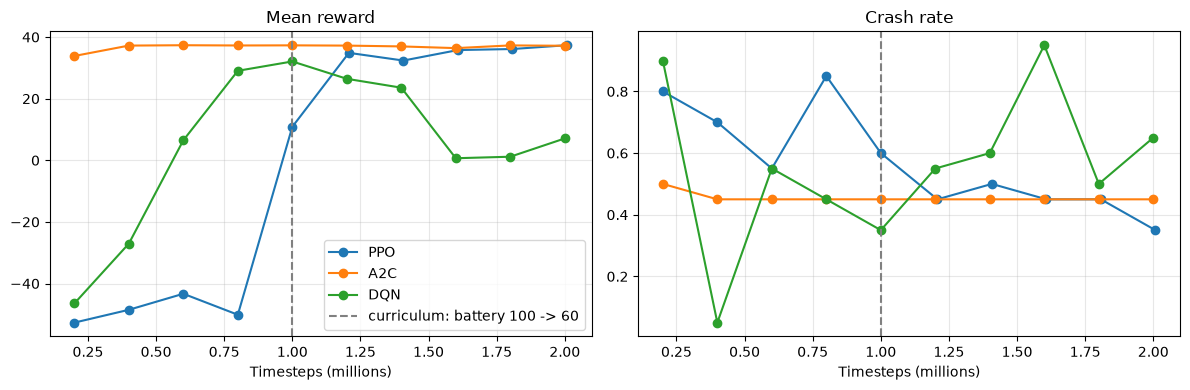

In [15]:
plot_histories({"PPO": ppo_hist, "A2C": a2c_hist, "DQN": dqn_hist}, "results/learning_curves_default.png")

Cada algoritmo apresentou uma dinâmica de aprendizado diferente:

- PPO: ficou no platô de não fazer nada durante quase toda a primeira fase e só começou a entregar perto de 1 milhão de passos. Na segunda fase, estabilizou em torno de 37 de recompensa, com 35% de queda.
- A2C: aprendeu muito mais rápido, já com 200 mil passos. Faz sentido: ele atualiza a rede a cada 5 passos por ambiente, enquanto o PPO acumula 2048 passos por atualização. Porém, a política estabilizou cedo e praticamente não mudou na segunda fase, mantendo cerca de 45% de queda.
- DQN: aprendeu bem na primeira fase (32 de recompensa ao fim dela), mas piorou na segunda, chegando a 95% de queda em uma das avaliações. Uma explicação provável é o replay buffer: com capacidade de 1 milhão de transições, ele continua cheio de experiências da primeira fase, em que a bateria durava muito mais, e o agente segue aprendendo com uma dinâmica que não existe mais. Essa é uma limitação conhecida de métodos off-policy combinados com currículo, e motivou incluir o tamanho do buffer na otimização.

### 4.2 Otimização de hiperparâmetros

As tabelas a seguir mostram todas as configurações testadas para cada algoritmo, ordenadas pela recompensa média nos 50 episódios de seleção. Como o treino é salvo por configuração, as células apenas carregam os resultados já calculados.

In [16]:
from itertools import product

SEARCH_SPACE = {
    "PPO": (PPO, {
        "learning_rate": [3e-4, 1e-4],
        "ent_coef": [0.01, 0.05],
        "n_steps": [512, 2048],
    }),
    "A2C": (A2C, {
        "learning_rate": [7e-4, 3e-4],
        "ent_coef": [0.01, 0.05],
        "n_steps": [5, 20],
    }),
    "DQN": (DQN, {
        "learning_rate": [1e-4, 5e-4],
        "exploration_fraction": [0.1, 0.3],
        "buffer_size": [1_000_000, 50_000],
    }),
}

def grid_search(algo_name, stage_steps=1_000_000):
    "Trains every config of the grid and appends the results to a CSV. Configs already in the CSV are skipped, so the search can be resumed"
    algo_cls, grid = SEARCH_SPACE[algo_name]
    search_file = f"results/hparam_{algo_name.lower()}.csv"
    done = pd.read_csv(search_file)["config_id"].tolist() if os.path.exists(search_file) else []

    for values in product(*grid.values()):
        params = dict(zip(grid.keys(), values))
        config_id = f"{algo_name}_" + "_".join(f"{k}={v}" for k, v in params.items())
        if config_id in done:
            print("skip", config_id)
            continue

        print("training", config_id)
        model, history = train_with_curriculum(
            algo_cls, stage_steps=stage_steps, eval_every=stage_steps, **params
        )
        res = evaluate(model_policy(model), n_episodes=50, seed=2000)
        row = {"config_id": config_id, **params, **res}
        pd.DataFrame([row]).to_csv(search_file, mode="a", index=False,
                                   header=not os.path.exists(search_file))
        history.to_csv(f"results/{config_id}_history.csv", index=False)

    return pd.read_csv(search_file).sort_values("reward_mean", ascending=False)

In [17]:
ppo_search = grid_search("PPO")
ppo_search.round(4)

skip PPO_learning_rate=0.0003_ent_coef=0.01_n_steps=512
skip PPO_learning_rate=0.0003_ent_coef=0.01_n_steps=2048
skip PPO_learning_rate=0.0003_ent_coef=0.05_n_steps=512
skip PPO_learning_rate=0.0003_ent_coef=0.05_n_steps=2048
skip PPO_learning_rate=0.0001_ent_coef=0.01_n_steps=512
skip PPO_learning_rate=0.0001_ent_coef=0.01_n_steps=2048
skip PPO_learning_rate=0.0001_ent_coef=0.05_n_steps=512
skip PPO_learning_rate=0.0001_ent_coef=0.05_n_steps=2048


,config_id,learning_rate,ent_coef,n_steps,reward_mean,reward_std,on_time_mean,late_mean,expired_mean,crash_rate
0,PPO_learning_rate=0.0003_ent_coef=0.01_n_steps...,0.0003,0.01,512,33.964,32.5354,2.08,0.38,0.22,0.36
1,PPO_learning_rate=0.0003_ent_coef=0.01_n_steps...,0.0003,0.01,2048,32.160,33.5081,2.06,0.38,0.18,0.40
3,PPO_learning_rate=0.0003_ent_coef=0.05_n_steps...,0.0003,0.05,2048,20.716,21.0314,1.34,0.48,1.12,0.08
5,PPO_learning_rate=0.0001_ent_coef=0.01_n_steps...,0.0001,0.01,2048,-19.540,6.2345,0.00,0.00,2.98,0.02
6,PPO_learning_rate=0.0001_ent_coef=0.05_n_steps...,0.0001,0.05,512,-19.702,6.8232,0.00,0.00,2.98,0.02
7,PPO_learning_rate=0.0001_ent_coef=0.05_n_steps...,0.0001,0.05,2048,-21.156,10.1703,0.00,0.00,3.00,0.04
4,PPO_learning_rate=0.0001_ent_coef=0.01_n_steps...,0.0001,0.01,512,-21.298,9.9044,0.00,0.00,2.92,0.06
2,PPO_learning_rate=0.0003_ent_coef=0.05_n_steps...,0.0003,0.05,512,-23.266,9.9915,0.00,0.00,3.00,0.04


Resultados do PPO:

- `learning_rate=1e-4` não aprendeu em nenhuma combinação: é lento demais para sair do platô inicial dentro do orçamento.
- `ent_coef=0.05` em geral atrapalhou: com tanta aleatoriedade, o agente cai com frequência na primeira fase e não descobre as entregas. A exceção foi a configuração (3e-4, 0.05, 2048), que aprendeu tarde e com um perfil diferente: bem menos quedas (8% contra cerca de 36%), mas menos entregas no prazo (1.34). É o trade-off entre prazo e bateria aparecendo por meio de um hiperparâmetro.
- A melhor configuração foi (3e-4, 0.01, 512), com 33.96, praticamente empatada com a padrão (3e-4, 0.01, 2048), com 32.16. Com desvio padrão em torno de 33 (alto porque cada queda custa -50), essa diferença está dentro do ruído da avaliação.

In [18]:
# Discarded first PPO search with half the budget (500k steps per stage)
pd.read_csv("results/hparam_ppo_500k.csv").sort_values("reward_mean", ascending=False).round(4)

,config_id,learning_rate,ent_coef,n_steps,reward_mean,reward_std,on_time_mean,late_mean,expired_mean,crash_rate
1,PPO_learning_rate=0.0003_ent_coef=0.01_n_steps...,0.0003,0.01,2048,-11.840,16.9047,0.3,0.0,2.64,0.04
5,PPO_learning_rate=0.0001_ent_coef=0.01_n_steps...,0.0001,0.01,2048,-18.656,1.4356,0.0,0.0,3.00,0.00
4,PPO_learning_rate=0.0001_ent_coef=0.01_n_steps...,0.0001,0.01,512,-18.666,1.4535,0.0,0.0,3.00,0.00
6,PPO_learning_rate=0.0001_ent_coef=0.05_n_steps...,0.0001,0.05,512,-19.784,7.1594,0.0,0.0,2.98,0.02
2,PPO_learning_rate=0.0003_ent_coef=0.05_n_steps...,0.0003,0.05,512,-20.576,2.3735,0.0,0.0,3.00,0.00
7,PPO_learning_rate=0.0001_ent_coef=0.05_n_steps...,0.0001,0.05,2048,-20.764,9.6305,0.0,0.0,2.98,0.04
0,PPO_learning_rate=0.0003_ent_coef=0.01_n_steps...,0.0003,0.01,512,-21.120,9.3650,0.0,0.0,2.96,0.04
3,PPO_learning_rate=0.0003_ent_coef=0.05_n_steps...,0.0003,0.05,2048,-24.070,11.6643,0.0,0.0,2.96,0.06


A tabela acima mostra a primeira busca do PPO, feita com metade do orçamento (500 mil passos por fase) e descartada. Nenhuma configuração aprendeu a entregar, exceto a padrão, que começou a fazer isso (0.3 entrega no prazo por episódio). Como vimos na seção 4.1, o PPO só sai do platô inicial perto de 1 milhão de passos, então essa busca media apenas quem aprende mais rápido, e não qual configuração chega mais longe. Isso justificou usar o orçamento completo em todas as buscas, o que também torna a comparação entre algoritmos justa.

In [19]:
a2c_search = grid_search("A2C")
a2c_search.round(4)

skip A2C_learning_rate=0.0007_ent_coef=0.01_n_steps=5
skip A2C_learning_rate=0.0007_ent_coef=0.01_n_steps=20
skip A2C_learning_rate=0.0007_ent_coef=0.05_n_steps=5
skip A2C_learning_rate=0.0007_ent_coef=0.05_n_steps=20
skip A2C_learning_rate=0.0003_ent_coef=0.01_n_steps=5
skip A2C_learning_rate=0.0003_ent_coef=0.01_n_steps=20
skip A2C_learning_rate=0.0003_ent_coef=0.05_n_steps=5
skip A2C_learning_rate=0.0003_ent_coef=0.05_n_steps=20


,config_id,learning_rate,ent_coef,n_steps,reward_mean,reward_std,on_time_mean,late_mean,expired_mean,crash_rate
6,A2C_learning_rate=0.0003_ent_coef=0.05_n_steps=5,0.0003,0.05,5,32.7607,34.4400,2.14,0.34,0.00,0.50
0,A2C_learning_rate=0.0007_ent_coef=0.01_n_steps=5,0.0007,0.01,5,32.6453,34.6338,2.14,0.34,0.00,0.50
4,A2C_learning_rate=0.0003_ent_coef=0.01_n_steps=5,0.0003,0.01,5,32.6120,34.5969,2.14,0.34,0.00,0.50
3,A2C_learning_rate=0.0007_ent_coef=0.05_n_steps=20,0.0007,0.05,20,32.5067,34.6055,2.14,0.34,0.00,0.50
1,A2C_learning_rate=0.0007_ent_coef=0.01_n_steps=20,0.0007,0.01,20,32.2740,34.6347,2.14,0.34,0.00,0.50
2,A2C_learning_rate=0.0007_ent_coef=0.05_n_steps=5,0.0007,0.05,5,31.7760,35.2608,2.12,0.36,0.00,0.50
7,A2C_learning_rate=0.0003_ent_coef=0.05_n_steps=20,0.0003,0.05,20,29.7907,32.3133,2.06,0.30,0.20,0.44
5,A2C_learning_rate=0.0003_ent_coef=0.01_n_steps=20,0.0003,0.01,20,26.3147,33.4308,2.02,0.38,0.02,0.56


Resultados do A2C:

- Quase todas as configurações convergiram para a mesma política: nos episódios de seleção, os números são praticamente idênticos (2.14 entregas no prazo, 0.34 atrasadas e 50% de queda). No A2C, os hiperparâmetros mudaram a velocidade de convergência, mas não o ponto de chegada.
- Com `n_steps=5`, todas as configurações já tinham convergido ao fim da primeira fase. Com `n_steps=20`, várias ficaram presas na primeira fase e só aprenderam na segunda.
- A configuração (3e-4, 0.05, 20) ilustra o ruído da avaliação: nos 20 episódios de acompanhamento ela marcou 42.6 com 20% de queda, mas nos 50 episódios de seleção ficou em 29.8 com 44%. Isso reforça a importância de usar mais episódios na avaliação final.
- A melhor foi (3e-4, 0.05, 5), com 32.76, empatada com as demais dentro do ruído.

In [20]:
dqn_search = grid_search("DQN")
dqn_search.round(4)

skip DQN_learning_rate=0.0001_exploration_fraction=0.1_buffer_size=1000000
skip DQN_learning_rate=0.0001_exploration_fraction=0.1_buffer_size=50000
skip DQN_learning_rate=0.0001_exploration_fraction=0.3_buffer_size=1000000
skip DQN_learning_rate=0.0001_exploration_fraction=0.3_buffer_size=50000
skip DQN_learning_rate=0.0005_exploration_fraction=0.1_buffer_size=1000000
skip DQN_learning_rate=0.0005_exploration_fraction=0.1_buffer_size=50000
skip DQN_learning_rate=0.0005_exploration_fraction=0.3_buffer_size=1000000
skip DQN_learning_rate=0.0005_exploration_fraction=0.3_buffer_size=50000


,config_id,learning_rate,exploration_fraction,buffer_size,reward_mean,reward_std,on_time_mean,late_mean,expired_mean,crash_rate
5,DQN_learning_rate=0.0005_exploration_fraction=...,0.0005,0.1,50000,30.6013,35.2439,2.06,0.40,0.00,0.50
7,DQN_learning_rate=0.0005_exploration_fraction=...,0.0005,0.3,50000,30.0153,34.0590,2.00,0.46,0.04,0.48
4,DQN_learning_rate=0.0005_exploration_fraction=...,0.0005,0.1,1000000,26.6287,35.0358,2.06,0.28,0.08,0.54
3,DQN_learning_rate=0.0001_exploration_fraction=...,0.0001,0.3,50000,25.3940,33.6280,2.06,0.32,0.02,0.58
6,DQN_learning_rate=0.0005_exploration_fraction=...,0.0005,0.3,1000000,21.5220,38.0454,1.82,0.38,0.36,0.46
1,DQN_learning_rate=0.0001_exploration_fraction=...,0.0001,0.1,50000,12.8567,26.7497,1.68,0.14,0.64,0.46
2,DQN_learning_rate=0.0001_exploration_fraction=...,0.0001,0.3,1000000,2.1413,13.4144,1.82,0.10,0.12,0.88
0,DQN_learning_rate=0.0001_exploration_fraction=...,0.0001,0.1,1000000,-2.9847,25.2218,1.48,0.18,0.46,0.72


Resultados do DQN:

- Ao contrário do PPO e do A2C, a otimização fez muita diferença. A configuração padrão (1e-4, 0.1, 1000000) foi a pior de todas, com -2.98, reproduzindo a degradação na segunda fase vista na seção 4.1.
- O buffer de 50 mil transições melhorou o resultado em todos os quatro pares de `learning_rate` e `exploration_fraction` (na configuração padrão, de -2.98 para 12.86), confirmando a hipótese de que experiências antigas da primeira fase prejudicavam o aprendizado.
- `learning_rate=5e-4` foi melhor que 1e-4 em todas as combinações.
- A melhor foi (5e-4, 0.1, 50000), com 30.60, um ganho de mais de 33 pontos sobre a padrão.

### 4.3 Experimento adicional: gamma do shaping

Nos três algoritmos, as melhores configurações ficaram com taxa de queda entre 35% e 50%. Quando um comportamento se repete independentemente do algoritmo e dos hiperparâmetros, a causa provavelmente está no ambiente ou na recompensa.

A hipótese testada foi o desconto do shaping. Como descrito na seção 3.3, o shaping usa desconto 1.0 enquanto os algoritmos usam 0.99, o que remove a garantia de que ele não altera a política ótima. O efeito esperado recai justamente sobre a recarga: desviar até a estação significa afastar-se do alvo, o que gera penalidade de shaping imediata, enquanto a compensação só vem depois, descontada. O desvio pareceria pior do que realmente é, levando o agente a arriscar.

Para testar, a melhor configuração do PPO foi treinada novamente com o shaping usando desconto 0.99. A avaliação é feita no ambiente padrão, então as métricas são comparáveis com a busca (33.96 de recompensa e 36% de queda nos mesmos 50 episódios).

In [21]:
exp_model, exp_hist = run_and_save(
    "ppo_shaping_gamma_099", PPO,
    learning_rate=3e-4, ent_coef=0.01, n_steps=512,
    env_kwargs={"shaping_gamma": 0.99},
)
exp_res = evaluate(model_policy(exp_model), n_episodes=50, seed=2000)
pd.DataFrame([exp_res]).round(3)

loading ppo_shaping_gamma_099


,reward_mean,reward_std,on_time_mean,late_mean,expired_mean,crash_rate
0,-20.512,9.235,0.0,0.0,2.96,0.04


O resultado foi negativo: com desconto 0.99 no shaping, o agente não aprendeu a entregar, em nenhuma das duas fases do currículo (histórico em `results/ppo_shaping_gamma_099_history.csv`). Voltou ao comportamento de ficar parado.

A explicação está na fórmula do shaping. Com desconto 0.99, cada passo recebe um termo extra de (0.99 - 1) x Phi(s) = -0.01 x Phi(s). Como o potencial cresce com o progresso (7 por estágio concluído), quanto mais o agente avança, maior fica essa penalidade por passo. Na prática, o shaping passa a punir o agente por ter progredido, e não fazer nada volta a ser atraente.

Isso evidencia um trade-off: o shaping com o mesmo desconto do algoritmo tem a garantia teórica de preservar a política ótima, mas neste ambiente impediu o aprendizado. O desconto 1.0 foi necessário para o agente aprender, ao custo de perder essa garantia, o que ajuda a explicar a tendência a arriscar a bateria. Como limitação, o experimento usou uma única execução.

### 4.4 Avaliação final

A melhor configuração de cada algoritmo foi treinada novamente com o orçamento completo, e o modelo salvo. Em seguida, todas as políticas foram avaliadas nos mesmos 100 episódios, com seeds a partir de 10000, que não foram usadas nem no treino nem na seleção. Os modelos com hiperparâmetros padrão da seção 4.1 também entram na comparação, para medir o ganho da otimização.

In [22]:
best_configs = {
    "PPO": (PPO, {"learning_rate": 3e-4, "ent_coef": 0.01, "n_steps": 512}),
    "A2C": (A2C, {"learning_rate": 3e-4, "ent_coef": 0.05, "n_steps": 5}),
    "DQN": (DQN, {"learning_rate": 5e-4, "exploration_fraction": 0.1, "buffer_size": 50_000}),
}

best_models = {}
for name, (algo_cls, params) in best_configs.items():
    path = f"models/{name.lower()}_best"
    if os.path.exists(path + ".zip"):
        print("loading", name)
        best_models[name] = algo_cls.load(path, device="cpu")
    else:
        print("training", name)
        best_models[name], _ = run_and_save(f"{name.lower()}_best", algo_cls, **params)

loading PPO
loading A2C
loading DQN


In [23]:
FINAL_EPISODES, FINAL_SEED = 100, 10_000

def final_eval(policy_fn):
    set_random_seed(FINAL_SEED)  # makes stochastic action sampling reproducible
    return evaluate(policy_fn, FINAL_EPISODES, FINAL_SEED)

default_models = {"PPO": ppo_model, "A2C": a2c_model, "DQN": dqn_model}

final = {
    "random": final_eval(random_policy),
    "greedy": final_eval(greedy_policy),
}
for name in ["PPO", "A2C", "DQN"]:
    final[f"{name} default"] = final_eval(model_policy(default_models[name]))
    final[f"{name} tuned"] = final_eval(model_policy(best_models[name]))

final_df = pd.DataFrame(final).T
final_df.to_csv("results/final_evaluation.csv")
final_df.round(3)

,reward_mean,reward_std,on_time_mean,late_mean,expired_mean,crash_rate
random,-36.161,14.207,0.00,0.01,2.89,0.10
greedy,9.803,20.530,0.82,0.20,1.98,0.00
PPO default,35.029,32.470,2.06,0.38,0.20,0.34
PPO tuned,39.491,28.639,2.09,0.29,0.45,0.16
A2C default,34.622,36.358,2.20,0.26,0.04,0.46
A2C tuned,33.915,35.362,2.22,0.24,0.00,0.49
DQN default,8.802,20.710,1.70,0.22,0.43,0.63
DQN tuned,24.979,32.723,1.87,0.43,0.26,0.43


Todos os agentes treinados superam com folga os dois baselines. O melhor foi o PPO otimizado, com 39.5 de recompensa média e a menor taxa de queda entre os agentes (16%).

O efeito da otimização variou bastante entre os algoritmos:

- PPO: a otimização reduziu a taxa de queda pela metade (de 34% para 16%), em troca de um pouco mais de pacotes expirados (de 0.20 para 0.45). A recompensa subiu de 35.0 para 39.5.
- A2C: sem efeito relevante (34.6 contra 33.9), coerente com a busca, em que todas as configurações convergiam para a mesma política.
- DQN: o maior ganho, de 8.8 para 25.0, com a taxa de queda caindo de 63% para 43%, principalmente graças ao buffer menor.

Comparando os agentes otimizados com a heurística, aparece com clareza o trade-off entre prazo e bateria. A heurística nunca cai, mas deixa quase 2 pacotes expirarem por episódio. O A2C é o extremo oposto: nunca deixa pacote expirar, mas cai em quase metade dos episódios. O PPO fica no meio, com o melhor equilíbrio.

Um cuidado na interpretação: com desvios padrão entre 28 e 36 em 100 episódios, o erro padrão das médias fica em torno de 3. A diferença entre PPO e A2C otimizados (5.6) é da ordem de uma vez o erro combinado das duas médias; ela sugere que o PPO é melhor, mas não permite afirmar uma superioridade estatística clara. Já as diferenças para os baselines e o ganho do DQN com a otimização são bem maiores que o ruído.

### 4.5 Visualização dos resultados

As curvas abaixo mostram o aprendizado das configurações otimizadas. A linha tracejada marca a mudança de fase do currículo. Cada ponto usa 20 episódios, e na taxa de queda cada episódio vale 5 pontos percentuais, então as curvas são ruidosas: a tendência importa mais que os pontos individuais, e a referência de desempenho é a tabela da seção 4.4.

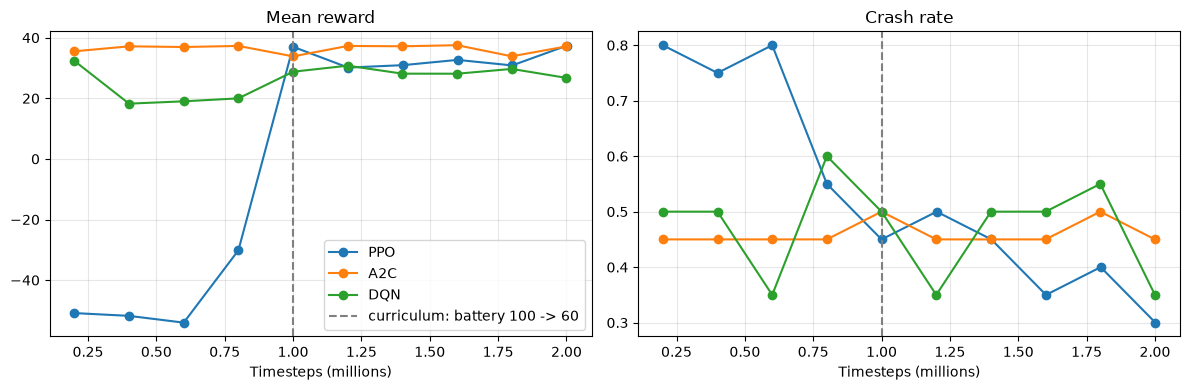

In [24]:
names = ["PPO", "A2C", "DQN"]
plot_histories({n: pd.read_csv(f"results/{n.lower()}_best_history.csv") for n in names},
               "results/learning_curves.png")

Os gráficos a seguir resumem a avaliação final. O gráfico central mostra o destino dos 3 pacotes de cada episódio: entregues no prazo, atrasados, expirados, ou perdidos porque o drone caiu antes de entregá-los. É nele que o trade-off fica mais visível: a heurística perde pacotes por expiração (vermelho), enquanto os agentes perdem principalmente por queda (cinza).

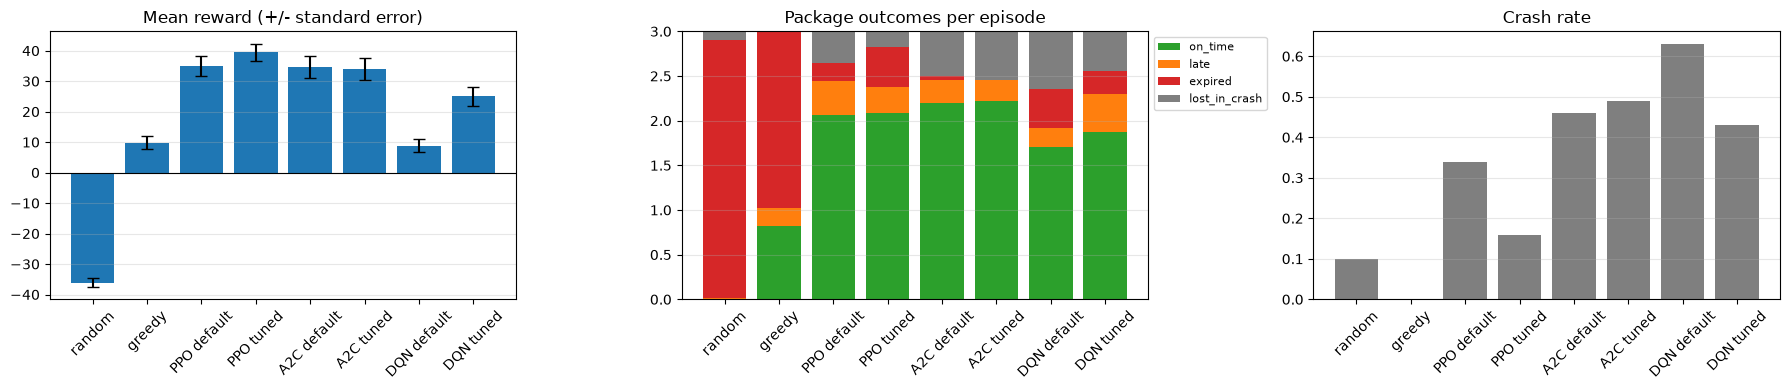

In [25]:
final_df = pd.read_csv("results/final_evaluation.csv", index_col=0)
labels = final_df.index
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Mean reward with standard error
se = final_df["reward_std"] / np.sqrt(FINAL_EPISODES)
axes[0].bar(labels, final_df["reward_mean"], yerr=se, capsize=4, color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Mean reward (+/- standard error)")

# Package outcomes per episode (what is left up to N_PACKAGES was lost in a crash)
outcomes = final_df[["on_time_mean", "late_mean", "expired_mean"]].copy()
outcomes["lost_in_crash"] = N_PACKAGES - outcomes.sum(axis=1)
colors = {"on_time_mean": "tab:green", "late_mean": "tab:orange",
          "expired_mean": "tab:red", "lost_in_crash": "tab:gray"}
bottom = np.zeros(len(labels))
for col, color in colors.items():
    axes[1].bar(labels, outcomes[col], bottom=bottom, color=color,
                label=col.replace("_mean", ""))
    bottom += outcomes[col].values
axes[1].set_title("Package outcomes per episode")
axes[1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.0, 1.0))

# Crash rate
axes[2].bar(labels, final_df["crash_rate"], color="tab:gray")
axes[2].set_title("Crash rate")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    
plt.tight_layout()
plt.savefig("results/final_comparison.png", dpi=150)
plt.show()

Por fim, dois episódios do PPO otimizado foram gravados como GIF usando o modo `rgb_array` do render: um em que o drone entrega os 3 pacotes e outro em que ele cai por falta de bateria. Os arquivos ficam em `results/ppo_success.gif` e `results/ppo_crash.gif`. Abaixo, o episódio de sucesso.

In [26]:
from PIL import Image

def record_episode(model, seed):
    env = gym.make("DroneDelivery-v0", render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames, done = [env.render()], False
    while not done:
        action, _ = model.predict(obs, deterministic=False)
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        done = terminated or truncated
    return frames, info

def save_gif(frames, path, ms_per_frame=300):
    images = [Image.fromarray(f) for f in frames]
    images[0].save(path, save_all=True, append_images=images[1:],
                   duration=ms_per_frame, loop=0)

# Find one successful episode and one crash episode for the best agent
set_random_seed(0)
found = {}
for seed in range(20_000, 20_050):
    frames, info = record_episode(best_models["PPO"], seed)
    delivered = info["on_time"] + info["late"]
    if "success" not in found and delivered == N_PACKAGES and not info["crashed"]:
        found["success"] = (seed, frames)
    if "crash" not in found and info["crashed"]:
        found["crash"] = (seed, frames)
    if len(found) == 2:
        break

for kind, (seed, frames) in found.items():
    save_gif(frames, f"results/ppo_{kind}.gif")
    print(f"{kind}: seed={seed}, {len(frames)} frames")

success: seed=20001, 38 frames
crash: seed=20002, 39 frames


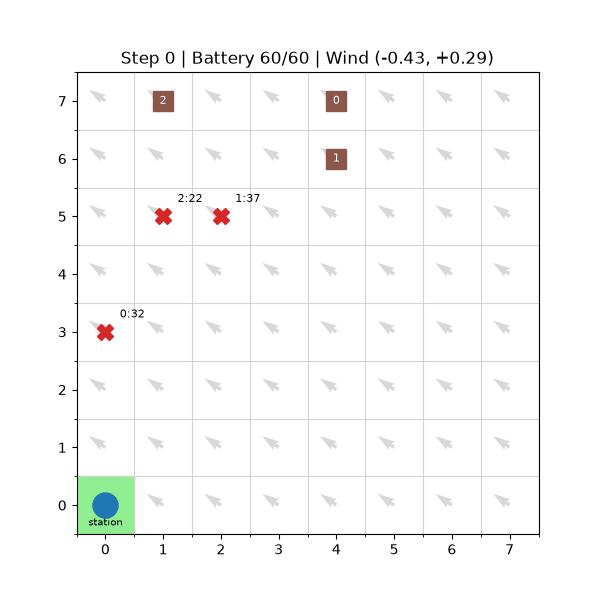

In [27]:
from IPython.display import Image as ShowImage
ShowImage(filename="results/ppo_success.gif")

## 5. Conclusões

Este trabalho modelou e implementou um ambiente inédito no Gymnasium, em que um drone precisa entregar pacotes com prazo sob vento variável e bateria limitada, e comparou três algoritmos de aprendizado por reforço profundo do stable-baselines3. Os três aprenderam políticas muito superiores aos baselines: o melhor agente, o PPO otimizado, obteve 39.5 de recompensa média, contra 9.8 da heurística e -36.2 da política aleatória, entregando em média 2.38 dos 3 pacotes por episódio.

O resultado mais interessante é que as políticas aprendidas expressam de formas diferentes o trade-off entre prazo e bateria que motivou o problema. A heurística nunca cai, mas perde quase 2 pacotes por expiração; o A2C nunca deixa pacote expirar, mas cai em quase metade dos episódios; o PPO otimizado encontrou o melhor equilíbrio, com 16% de queda. A otimização de hiperparâmetros também teve efeitos distintos: grande no DQN (principalmente pelo tamanho do replay buffer), moderado no PPO (redução da taxa de queda pela metade) e nulo no A2C.

Dificuldades encontradas

A maior parte do esforço foi tornar o problema aprendível. A primeira versão levou o agente a ficar parado, e a solução exigiu várias etapas, cada uma validada com experimentos de diagnóstico: reward shaping baseado em potencial (com duas recalibrações), vetores relativos ao alvo e à estação na observação, um orçamento de treino maior e um currículo de bateria. Uma lição importante foi separar problemas do ambiente de problemas de aprendizado: a política heurística confirmou que o ambiente estava correto quando os agentes ainda não aprendiam.

Também houve uma dificuldade de calibração do próprio problema: com a bateria inicial de 100, os agentes quase nunca precisavam recarregar, e o trade-off da proposta não aparecia. Medir isso levou à redução da capacidade para 60.

Por fim, o custo computacional influenciou a metodologia: uma primeira busca de hiperparâmetros com metade do orçamento teve que ser descartada, porque o PPO precisa de cerca de 1 milhão de passos para sair do platô inicial.

Limitações

- Cada configuração foi treinada com uma única seed. O retreino da melhor configuração do PPO, com a mesma seed, não reproduziu exatamente a curva da busca, o que indica variância relevante entre execuções. O ideal seria treinar cada configuração com várias seeds e comparar as médias.
- Com os desvios observados, parte das diferenças entre agentes (por exemplo, PPO e A2C otimizados) está próxima do ruído da avaliação.
- O shaping usa desconto 1.0, diferente do desconto dos algoritmos, e por isso não tem a garantia teórica de preservar a política ótima. O experimento da seção 4.3 mostrou que a alternativa teoricamente correta impediu o aprendizado, então a escolha foi mantida, mas ela provavelmente contribui para a tendência dos agentes a arriscar a bateria.
- A taxa de queda do melhor agente (16%) seria inaceitável em uma operação real.
- O ambiente tem simplificações: vento global em vez de um campo por célula, grid pequeno, número fixo de pacotes e um único drone.

Trabalhos futuros

- Repetir os experimentos com várias seeds e usar testes estatísticos nas comparações.
- Investigar formas de shaping que considerem a bateria, por exemplo um potencial que leve em conta a necessidade de voltar à estação, ou abordagens de aprendizado por reforço com restrições, tratando a queda como uma restrição de segurança em vez de apenas uma penalidade.
- Testar um currículo mais gradual (por exemplo 100, 80 e 60), que pode facilitar a transição para a bateria real, principalmente no DQN.
- Tornar o ambiente mais realista: campo de vento por célula, previsão de vento na observação, mais pacotes, pacotes que surgem durante o episódio e múltiplos drones.
- Usar métodos de busca de hiperparâmetros mais eficientes, como otimização bayesiana, para explorar espaços maiores com o mesmo custo.